# AQ-DPFL Full Working Dissertation Pipeline

**Cardiovascular Disease Prediction using a Privacy-Preserving Heterogeneous Real-Time Federated Learning Framework**

This Kaggle-ready notebook implements ECG loading, CNN-BiLSTM modelling, real-time streaming, heterogeneous clients, five comparative privacy methods, automatic result tables, privacy/accuracy plots, and final AQ-DPFL evaluation.

Methods compared:
1. FedAvg (no privacy)
2. Fixed DP-FedAvg
3. Secure Aggregation FL
4. Adaptive DP-FedAvg
5. **AQ-DPFL (proposed)**

> Secure aggregation and epsilon accounting are research simulations for comparative experiments, not production cryptography or formal privacy guarantees.

In [1]:
# 1. Imports and reproducibility
import os, time, math, random, zipfile, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef, classification_report,
    confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Input, Conv1D, BatchNormalization, MaxPooling1D,
    Dropout, LayerNormalization, Bidirectional, LSTM, GlobalMaxPooling1D, Dense)
SEED=42
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:',tf.__version__)
print('GPU:',tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration
Use `QUICK_MODE=True` to verify the complete pipeline. Set it to `False` for the dissertation experiment.

In [2]:
QUICK_MODE=True
NUM_CLIENTS=4; NUM_CLASSES=6
if QUICK_MODE:
    FED_ROUNDS=2; STREAM_CHUNK_SIZE=384; LOCAL_EPOCHS_BASE=1; MAX_SAMPLES=4000; MODEL_VARIANT='small'
else:
    FED_ROUNDS=10; STREAM_CHUNK_SIZE=2048; LOCAL_EPOCHS_BASE=3; MAX_SAMPLES=None; MODEL_VARIANT='medium'
LOCAL_BATCH_SIZE=32; DELTA=1e-5
FIXED_CLIP_NORM=5.0; FIXED_NOISE_MULTIPLIER=0.01
ADAPTIVE_BASE_NOISE=0.02; ADAPTIVE_MIN_NOISE=0.002
AQ_BASE_NOISE=0.012; AQ_MIN_NOISE=0.001; AQ_MAX_NOISE=0.03; AQ_BASE_CLIP=5.0
CLIENT_CONFIGS=[
 {'name':'Hospital-A','epochs':LOCAL_EPOCHS_BASE+1,'lr':1e-3,'latency':0.0},
 {'name':'Hospital-B','epochs':LOCAL_EPOCHS_BASE,'lr':8e-4,'latency':0.05},
 {'name':'Hospital-C','epochs':LOCAL_EPOCHS_BASE+1,'lr':6e-4,'latency':0.1},
 {'name':'Hospital-D','epochs':LOCAL_EPOCHS_BASE,'lr':1.2e-3,'latency':0.0},]
METHODS=['FedAvg','DP-FedAvg','Secure Aggregation','Adaptive DP-FedAvg','AQ-DPFL']

## Data loading and preprocessing

In [3]:
CLIENT_ZENODO_URL='https://zenodo.org/records/16739305/files/ecg_aug_model1.zip?download=1'
WORK_DIR=Path('/kaggle/working'); DATA_DIR=WORK_DIR/'dataset'; DATA_DIR.mkdir(parents=True,exist_ok=True)
def find_npz_directory(root):
    root=Path(root)
    if not root.exists(): return None
    for p in root.rglob('*'):
        if p.is_dir() and any(p.glob('*.npz')): return p
    return None
def download_file(url,path):
    import requests
    with requests.get(url,stream=True,timeout=180) as r:
        r.raise_for_status()
        with open(path,'wb') as f:
            for chunk in r.iter_content(8192):
                if chunk: f.write(chunk)
def process_npz_files(directory,max_samples=None):
    files=sorted(Path(directory).glob('*.npz'))
    if max_samples: files=files[:max_samples]
    if not files: raise FileNotFoundError(directory)
    X=[]; labels=[]
    for fp in tqdm(files,desc='Loading ECG'):
        with np.load(fp) as data:
            X.append(data['x']); labels.append(int(np.asarray(data['y']).item()))
    X=np.asarray(X,dtype='float32'); labels=np.asarray(labels)
    classes,indexed=np.unique(labels,return_inverse=True)
    y=np.eye(len(classes),dtype='float32')[indexed]
    return X,y,classes
def make_synthetic_ecg(n=3000,timesteps=600,channels=8,n_classes=6):
    print('WARNING: synthetic fallback used; use real ECG data for dissertation results.')
    rng=np.random.default_rng(SEED); labels=rng.integers(0,n_classes,size=n)
    X=rng.normal(0,.35,size=(n,timesteps,channels)).astype('float32'); t=np.linspace(0,1,timesteps)
    for i,c in enumerate(labels):
        wave=np.sin(2*np.pi*(3+c)*t)+.35*np.sin(2*np.pi*(5+c)*t)
        X[i,:,0]+=wave.astype('float32'); X[i,:,c%channels]+=.45*wave.astype('float32')
    return X,np.eye(n_classes,dtype='float32')[labels],np.arange(n_classes)
def load_ecg_data():
    p=find_npz_directory('/kaggle/input') or find_npz_directory(DATA_DIR)
    if p is not None: return process_npz_files(p,MAX_SAMPLES)
    try:
        zp=WORK_DIR/'ecg_aug_model1.zip'; download_file(CLIENT_ZENODO_URL,zp)
        with zipfile.ZipFile(zp) as z: z.extractall(DATA_DIR)
        p=find_npz_directory(DATA_DIR)
        if p is not None: return process_npz_files(p,MAX_SAMPLES)
    except Exception as e: print('Download failed:',repr(e))
    return make_synthetic_ecg(3000 if QUICK_MODE else 10000)
X,y,classes=load_ecg_data()
mean=X.mean(axis=(0,1),keepdims=True); std=X.std(axis=(0,1),keepdims=True)+1e-6
X=((X-mean)/std).astype('float32')
X_train_full,X_test,y_train_full,y_test=train_test_split(X,y,test_size=.2,random_state=SEED,stratify=np.argmax(y,axis=1))
print(X_train_full.shape,X_test.shape)

Loading ECG:   0%|          | 0/4000 [00:00<?, ?it/s]

(3200, 600, 8) (800, 600, 8)


## Heterogeneous non-IID hospital clients

In [4]:
def create_non_iid_clients(X,y,n_clients=4,alpha=1.5):
    labels=np.argmax(y,axis=1); client_idx=[[] for _ in range(n_clients)]
    for c in range(y.shape[1]):
        idx=np.where(labels==c)[0]; np.random.shuffle(idx)
        cuts=(np.cumsum(np.random.dirichlet(alpha*np.ones(n_clients)))*len(idx)).astype(int)[:-1]
        for j,part in enumerate(np.split(idx,cuts)): client_idx[j].extend(part.tolist())
    clients=[]
    for idx in client_idx:
        idx=np.asarray(idx); np.random.shuffle(idx)
        if len(idx)<100:
            idx=np.concatenate([idx,np.random.choice(np.arange(len(X)),100-len(idx),replace=True)])
        clients.append((X[idx],y[idx]))
    return clients
client_datasets=create_non_iid_clients(X_train_full,y_train_full,NUM_CLIENTS,alpha=1.5)
rows=[]
for i,(cx,cy) in enumerate(client_datasets):
    dist=np.bincount(np.argmax(cy,axis=1),minlength=NUM_CLASSES)
    rows.append({'Client':CLIENT_CONFIGS[i]['name'],'Samples':len(cx),'Epochs':CLIENT_CONFIGS[i]['epochs'],
                 'Learning Rate':CLIENT_CONFIGS[i]['lr'],**{f'Class_{k}':int(dist[k]) for k in range(NUM_CLASSES)}})
client_summary_df=pd.DataFrame(rows); display(client_summary_df)

,Client,Samples,Epochs,Learning Rate,Class_0,Class_1,Class_2,Class_3,Class_4,Class_5
0,Hospital-A,430,2,0.0010,67,37,109,133,22,62
1,Hospital-B,735,1,0.0008,90,118,170,46,293,18
2,Hospital-C,885,2,0.0006,176,102,116,123,190,178
3,Hospital-D,1150,1,0.0012,210,294,123,146,77,300


## CNN-BiLSTM model

In [5]:
def build_cnn_bilstm(input_shape,n_classes,variant='small'):
    reg=tf.keras.regularizers.l2(1e-4)
    if variant=='small': filters,l1,l2,dense,drop=48,48,24,48,.25
    else: filters,l1,l2,dense,drop=96,96,48,96,.35
    return Sequential([Input(shape=input_shape),Conv1D(filters,7,padding='same',activation='relu',kernel_regularizer=reg),
      BatchNormalization(),Conv1D(filters,5,padding='same',activation='relu',kernel_regularizer=reg),
      BatchNormalization(),MaxPooling1D(3),Dropout(drop),Conv1D(filters,5,padding='same',activation='relu',kernel_regularizer=reg),
      BatchNormalization(),MaxPooling1D(3),Dropout(drop),LayerNormalization(),
      Bidirectional(LSTM(l1,return_sequences=True,kernel_regularizer=reg)),Dropout(drop),
      Bidirectional(LSTM(l2,return_sequences=True,kernel_regularizer=reg)),GlobalMaxPooling1D(),Dropout(drop),
      Dense(dense,activation='relu',kernel_regularizer=reg),Dropout(drop),Dense(n_classes,activation='softmax')])
def compile_model(model,lr):
    model.compile(optimizer=tf.keras.optimizers.Adam(float(lr)),loss='categorical_crossentropy',metrics=['accuracy']); return model
def create_global_model(): return compile_model(build_cnn_bilstm(X.shape[1:],y.shape[1],MODEL_VARIANT),1e-3)
m=create_global_model(); m.summary(); del m; tf.keras.backend.clear_session()

I0000 00:00:1784732308.395062      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 600, 48)        │         2,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 600, 48)        │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 600, 48)        │        11,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 600, 48)        │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 200, 48)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 48)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 48)        │        11,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200, 48)        │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 66, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 66, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 66, 48)         │            96 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 66, 96)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 66, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 66, 48)         │        23,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 48)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         2,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,670 (350.27 KB)

 Trainable params: 89,382 (349.15 KB)

 Non-trainable params: 288 (1.12 KB)

## Evaluation, aggregation and privacy utilities

In [12]:
def evaluate_model(model,Xe,ye,title='',plots=False):
    prob=model.predict(Xe,verbose=0); pred=np.argmax(prob,axis=1); true=np.argmax(ye,axis=1)
    out={'accuracy':accuracy_score(true,pred),'balanced_accuracy':balanced_accuracy_score(true,pred),
         'precision_macro':precision_score(true,pred,average='macro',zero_division=0),
         'recall_macro':recall_score(true,pred,average='macro',zero_division=0),
         'f1_macro':f1_score(true,pred,average='macro',zero_division=0),'mcc':matthews_corrcoef(true,pred)}
    if title:
        print("\n" + title)
        for k, v in out.items():
            print(f"{k:20s}: {v:.4f}")
        
    if plots:
        cm=confusion_matrix(true,pred); plt.figure(figsize=(6,5)); plt.imshow(cm); plt.colorbar(); plt.title(title+' Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()
        truebin=label_binarize(true,classes=np.arange(ye.shape[1])); plt.figure(figsize=(7,5))
        for i in range(ye.shape[1]):
            try:
                fpr,tpr,_=roc_curve(truebin[:,i],prob[:,i]); plt.plot(fpr,tpr,label=f'Class {i}: {auc(fpr,tpr):.2f}')
            except ValueError: pass
        plt.plot([0,1],[0,1],'--'); plt.title(title+' ROC'); plt.legend(); plt.grid(); plt.show()
    return out
def clone_model_with_weights(source,lr):
    m=tf.keras.models.clone_model(source); m.set_weights(source.get_weights()); return compile_model(m,lr)
def compute_update(new,old): return [a-b for a,b in zip(new,old)]
def apply_update(weights,update): return [w+u for w,u in zip(weights,update)]
def update_l2_norm(update): return float(np.sqrt(sum(np.sum(u*u) for u in update)))
def clip_update(update,clip):
    norm=update_l2_norm(update); scale=min(1.,clip/(norm+1e-12)); return [u*scale for u in update],norm,scale
def add_noise(update,mult,clip):
    if mult<=0:return [u.copy() for u in update]
    std=mult*clip; return [u+np.random.normal(0,std,u.shape).astype(u.dtype) for u in update]
def weighted_average_updates(updates,counts):
    total=float(sum(counts)); return [sum(updates[i][l]*(counts[i]/total) for i in range(len(updates))) for l in range(len(updates[0]))]
def secure_aggregate_simulation(updates,counts):
    masked=[[u.copy() for u in upd] for upd in updates]
    for a in range(len(masked)):
        for b in range(a+1,len(masked)):
            for l in range(len(masked[0])):
                mask=np.random.normal(0,1e-6,masked[0][l].shape).astype(masked[0][l].dtype); masked[a][l]+=mask; masked[b][l]-=mask
    return weighted_average_updates(masked,counts)
def approximate_epsilon(rounds,mult,delta=1e-5):
    return np.inf if mult<=0 else float(np.sqrt(2*rounds*np.log(1/delta))/mult)
def normalized_entropy(yh):
    c=np.bincount(np.argmax(yh,axis=1),minlength=yh.shape[1]).astype(float); p=c/max(c.sum(),1); p=p[p>0]
    return float(-np.sum(p*np.log2(p))/np.log2(yh.shape[1]))
def data_quality_score(history,yh):
    losses=np.asarray(history.history.get('loss',[1.]),float); imp=max(0.,(losses[0]-losses[-1])/abs(losses[0])) if len(losses)>1 and losses[0]!=0 else 0.
    return float(np.clip(.4*normalized_entropy(yh)+.35/(1+np.std(losses))+.25*imp,0,1))
def adaptive_dp_parameters(r,total):
    progress=r/total; return 5.,float(ADAPTIVE_MIN_NOISE+(ADAPTIVE_BASE_NOISE-ADAPTIVE_MIN_NOISE)*(1-progress))
def aq_dpfl_parameters(dqa,r,total,norm,samples):
    q=1-np.clip(dqa,0,1); rf=1-r/total; sens=np.tanh(norm/10); sf=np.clip(10/np.sqrt(max(samples,1)),0,1)
    noise=float(np.clip(AQ_MIN_NOISE+AQ_BASE_NOISE*(.45*q+.25*rf+.2*sens+.1*sf),AQ_MIN_NOISE,AQ_MAX_NOISE))
    clip=float(np.clip(AQ_BASE_CLIP*(.75+.5*dqa),2,8)); return clip,noise

## Full federated experiment runner

In [15]:
def next_stream_chunk(Xc,yc,pos,size,rng):
    if pos>=len(Xc):
        order=rng.permutation(len(Xc)); Xc,yc=Xc[order],yc[order]; pos=0
    end=min(pos+size,len(Xc)); return Xc[pos:end],yc[pos:end],end,Xc,yc
def run_federated_experiment(method):
    if method not in METHODS: raise ValueError(method)
    print("\n" + "#" * 80)
    print(f"RUNNING {method}")
    print("#" * 80)
    tf.keras.backend.clear_session(); np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)
    gm=create_global_model(); gw=gm.get_weights(); clients=[(a.copy(),b.copy()) for a,b in client_datasets]; positions=[0]*NUM_CLIENTS
    round_rows=[]; privacy_rows=[]; start_all=time.time()
    for rnd in range(1,FED_ROUNDS+1):
        updates=[]; sample_counts=[]; start_round=time.time()
        for cid,(cx,cy) in enumerate(clients):
            cfg=CLIENT_CONFIGS[cid]; rng=np.random.default_rng(SEED+rnd*100+cid)
            Xs,ys,pos,cx,cy=next_stream_chunk(cx,cy,positions[cid],STREAM_CHUNK_SIZE,rng); clients[cid]=(cx,cy); positions[cid]=pos
            if len(Xs)<20: continue
            labels=np.argmax(ys,axis=1); _,counts=np.unique(labels,return_counts=True); strat=labels if len(counts)>1 and counts.min()>=2 and len(Xs)>=40 else None
            Xl,Xv,yl,yv=train_test_split(Xs,ys,test_size=.15,random_state=SEED+rnd+cid,stratify=strat)
            time.sleep(cfg['latency']); lm=clone_model_with_weights(gm,cfg['lr']); old=lm.get_weights()
            hist=lm.fit(Xl,yl,validation_data=(Xv,yv),epochs=cfg['epochs'],batch_size=LOCAL_BATCH_SIZE,
                        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)],verbose=0)
            raw=compute_update(lm.get_weights(),old); norm=update_l2_norm(raw); dqa=data_quality_score(hist,yl)
            if method=='FedAvg': processed=raw; clip=np.inf; noise=0.
            elif method=='DP-FedAvg':
                clip=FIXED_CLIP_NORM; noise=FIXED_NOISE_MULTIPLIER; processed=add_noise(clip_update(raw,clip)[0],noise,clip)
            elif method=='Secure Aggregation': processed=raw; clip=np.inf; noise=0.
            elif method=='Adaptive DP-FedAvg':
                clip,noise=adaptive_dp_parameters(rnd,FED_ROUNDS); processed=add_noise(clip_update(raw,clip)[0],noise,clip)
            else:
                clip,noise=aq_dpfl_parameters(dqa,rnd,FED_ROUNDS,norm,len(Xl)); processed=add_noise(clip_update(raw,clip)[0],noise,clip)
            updates.append(processed); sample_counts.append(len(Xl)); privacy_rows.append({'Method':method,'Round':rnd,'Client':cfg['name'],'DQA':dqa,
                'Raw Update Norm':norm,'Clip Norm':clip,'Noise Multiplier':noise,'Approx. Epsilon':approximate_epsilon(rnd,noise,DELTA),'Samples':len(Xl)})
            del lm
        if not updates: raise RuntimeError('No updates')
        agg=secure_aggregate_simulation(updates,sample_counts) if method in ['Secure Aggregation','AQ-DPFL'] else weighted_average_updates(updates,sample_counts)
        gw=apply_update(gw,agg); gm.set_weights(gw); metrics=evaluate_model(gm,X_test,y_test,f'{method} Round {rnd}',False)
        round_rows.append({'Method':method,'Round':rnd,**metrics,'Round Time (s)':time.time()-start_round})
    final=evaluate_model(gm,X_test,y_test,'FINAL '+method,False); final={'Method':method,**final,'Total Time (s)':time.time()-start_all}
    return {'model':gm,'final':final,'rounds':pd.DataFrame(round_rows),'privacy':pd.DataFrame(privacy_rows)}

## Run all five methods

In [16]:
all_experiments={}; finals=[]; rounds=[]; privacy=[]
for method in METHODS:
    res=run_federated_experiment(method); all_experiments[method]=res; finals.append(res['final']); rounds.append(res['rounds']); privacy.append(res['privacy'])
final_results_df=pd.DataFrame(finals); round_results_df=pd.concat(rounds,ignore_index=True); privacy_results_df=pd.concat(privacy,ignore_index=True)
display(final_results_df)


################################################################################
RUNNING FedAvg
################################################################################

FedAvg Round 1
accuracy            : 0.2000
balanced_accuracy   : 0.2118
precision_macro     : 0.1640
recall_macro        : 0.2118
f1_macro            : 0.1314
mcc                 : 0.0581

FedAvg Round 2
accuracy            : 0.2200
balanced_accuracy   : 0.2292
precision_macro     : 0.2443
recall_macro        : 0.2292
f1_macro            : 0.1813
mcc                 : 0.0780

FINAL FedAvg
accuracy            : 0.2200
balanced_accuracy   : 0.2292
precision_macro     : 0.2443
recall_macro        : 0.2292
f1_macro            : 0.1813
mcc                 : 0.0780

################################################################################
RUNNING DP-FedAvg
################################################################################

DP-FedAvg Round 1
accuracy            : 0.1900
balanced_accuracy   : 0.2

,Method,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,mcc,Total Time (s)
0,FedAvg,0.22000,0.229183,0.244269,0.229183,0.181292,0.078023,62.043622
1,DP-FedAvg,0.20000,0.198794,0.198420,0.198794,0.169019,0.037326,59.836380
2,Secure Aggregation,0.21125,0.219362,0.230454,0.219362,0.169743,0.066715,59.373251
3,Adaptive DP-FedAvg,0.20750,0.216276,0.202654,0.216276,0.174422,0.056592,59.227288
4,AQ-DPFL,0.21250,0.218098,0.218543,0.218098,0.159228,0.069384,59.698676


## Automatic dissertation-ready tables and graphs

,Method,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,mcc,Total Time (s)
0,FedAvg,22.00,22.92,24.43,22.92,18.13,0.0780,62.04
1,DP-FedAvg,20.00,19.88,19.84,19.88,16.90,0.0373,59.84
2,Secure Aggregation,21.12,21.94,23.05,21.94,16.97,0.0667,59.37
3,Adaptive DP-FedAvg,20.75,21.63,20.27,21.63,17.44,0.0566,59.23
4,AQ-DPFL,21.25,21.81,21.85,21.81,15.92,0.0694,59.70


,Method,Mean_DQA,Mean_Clip,Mean_Noise,Mean_Epsilon
0,AQ-DPFL,0.711331,5.528327,0.00445,1377.874601
1,Adaptive DP-FedAvg,0.711242,5.000000,0.00650,1914.649920
2,DP-FedAvg,0.711285,5.000000,0.01000,579.233317
3,FedAvg,0.711310,NaN,0.00000,NaN
4,Secure Aggregation,0.711326,NaN,0.00000,NaN


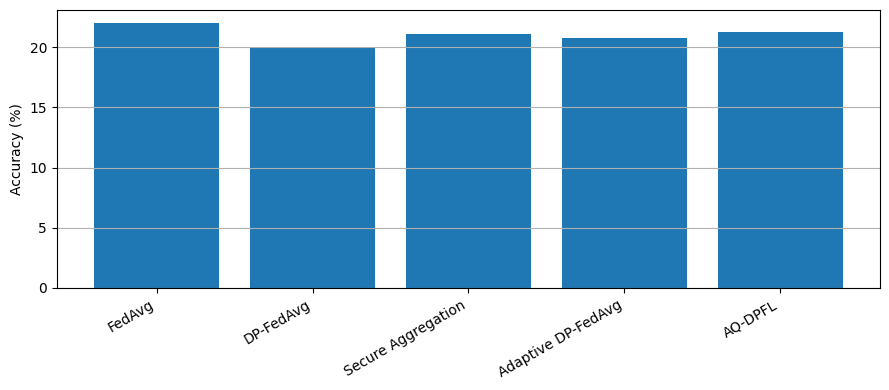

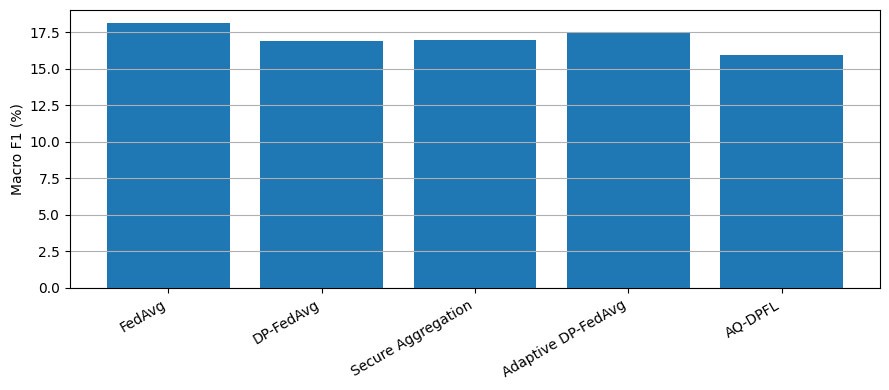

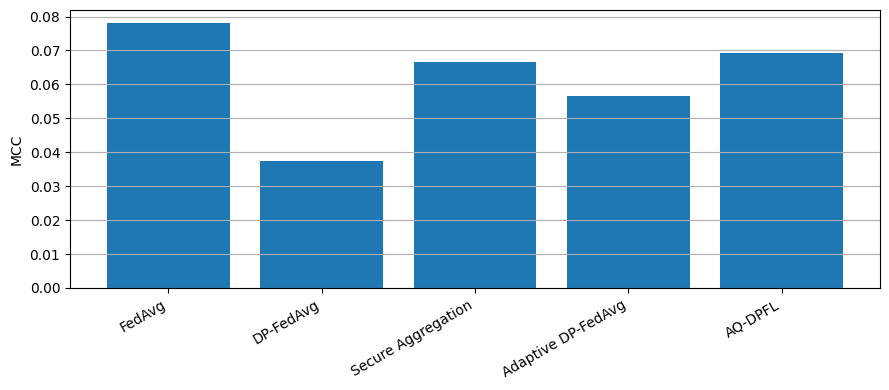

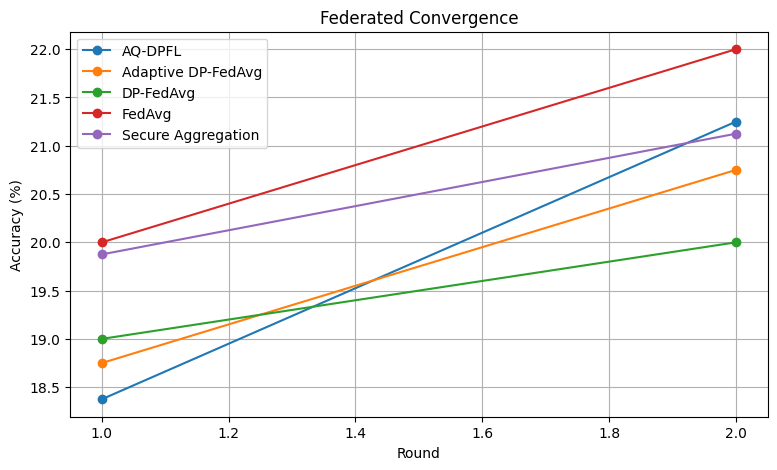

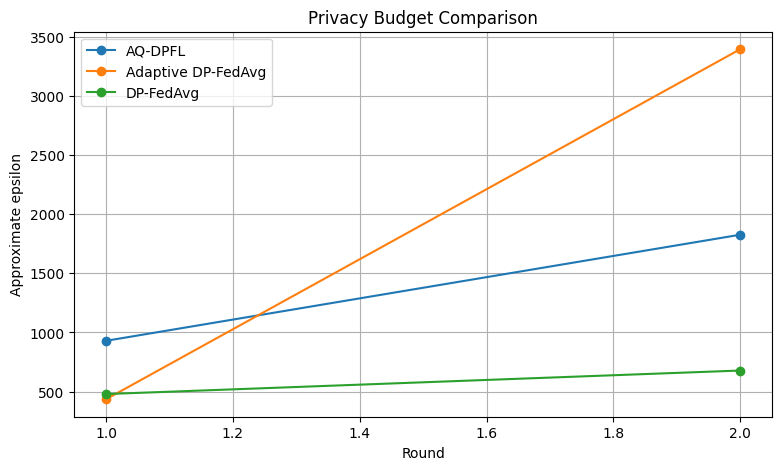

In [17]:
summary=final_results_df[['Method','accuracy','balanced_accuracy','precision_macro','recall_macro','f1_macro','mcc','Total Time (s)']].copy()
for c in ['accuracy','balanced_accuracy','precision_macro','recall_macro','f1_macro']: summary[c]=(100*summary[c]).round(2)
summary['mcc']=summary['mcc'].round(4); summary['Total Time (s)']=summary['Total Time (s)'].round(2)
display(summary)
privacy_summary=(privacy_results_df.replace([np.inf,-np.inf],np.nan).groupby('Method').agg(Mean_DQA=('DQA','mean'),
    Mean_Clip=('Clip Norm','mean'),Mean_Noise=('Noise Multiplier','mean'),Mean_Epsilon=('Approx. Epsilon','mean')).reset_index())
display(privacy_summary)
summary.to_csv('/kaggle/working/final_privacy_method_comparison.csv',index=False)
round_results_df.to_csv('/kaggle/working/federated_round_results.csv',index=False)
privacy_results_df.to_csv('/kaggle/working/privacy_client_round_results.csv',index=False)
for metric,label in [('accuracy','Accuracy (%)'),('f1_macro','Macro F1 (%)'),('mcc','MCC')]:
    plt.figure(figsize=(9,4)); vals=100*final_results_df[metric] if metric!='mcc' else final_results_df[metric]
    plt.bar(final_results_df['Method'],vals); plt.ylabel(label); plt.xticks(rotation=30,ha='right'); plt.grid(axis='y'); plt.tight_layout(); plt.show()
plt.figure(figsize=(9,5))
for method,g in round_results_df.groupby('Method'): plt.plot(g['Round'],100*g['accuracy'],marker='o',label=method)
plt.xlabel('Round'); plt.ylabel('Accuracy (%)'); plt.title('Federated Convergence'); plt.grid(); plt.legend(); plt.show()
eps=(privacy_results_df.replace([np.inf,-np.inf],np.nan).groupby(['Method','Round'])['Approx. Epsilon'].mean().reset_index())
plt.figure(figsize=(9,5))
for method,g in eps.groupby('Method'):
    if g['Approx. Epsilon'].notna().any(): plt.plot(g['Round'],g['Approx. Epsilon'],marker='o',label=method)
plt.xlabel('Round'); plt.ylabel('Approximate epsilon'); plt.title('Privacy Budget Comparison'); plt.grid(); plt.legend(); plt.show()

## Final detailed AQ-DPFL evaluation


AQ-DPFL Final
accuracy            : 0.2125
balanced_accuracy   : 0.2181
precision_macro     : 0.2185
recall_macro        : 0.2181
f1_macro            : 0.1592
mcc                 : 0.0694


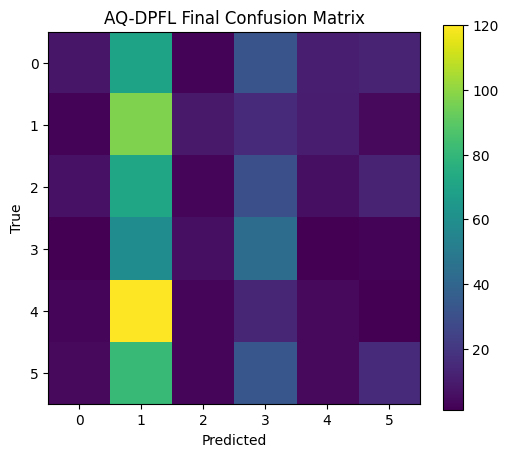

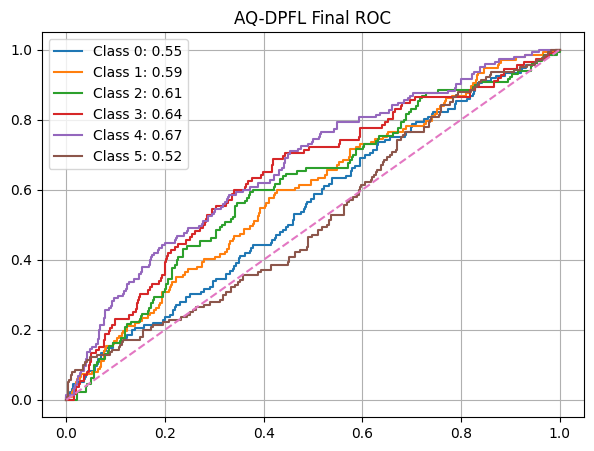

              precision    recall  f1-score   support

           0       0.32      0.06      0.10       136
           1       0.19      0.71      0.31       137
           2       0.12      0.02      0.04       130
           3       0.26      0.38      0.31       112
           4       0.11      0.03      0.04       145
           5       0.31      0.11      0.16       140

    accuracy                           0.21       800
   macro avg       0.22      0.22      0.16       800
weighted avg       0.22      0.21      0.15       800

Best accuracy: FedAvg (22.00%)
AQ-DPFL vs DP-FedAvg accuracy difference: 1.25 percentage points


In [18]:
aq_model=all_experiments['AQ-DPFL']['model']; aq_metrics=evaluate_model(aq_model,X_test,y_test,'AQ-DPFL Final',True)
prob=aq_model.predict(X_test,verbose=0); print(classification_report(np.argmax(y_test,axis=1),np.argmax(prob,axis=1),zero_division=0))
aq_model.save('/kaggle/working/AQ_DPFL_final_model.keras')
best=final_results_df.loc[final_results_df['accuracy'].idxmax()]
print(f"Best accuracy: {best['Method']} ({100*best['accuracy']:.2f}%)")
aq=final_results_df[final_results_df.Method=='AQ-DPFL'].iloc[0]; dp=final_results_df[final_results_df.Method=='DP-FedAvg'].iloc[0]
print(f"AQ-DPFL vs DP-FedAvg accuracy difference: {100*(aq.accuracy-dp.accuracy):.2f} percentage points")

## Dissertation interpretation

Discuss the measured results rather than assuming AQ-DPFL is automatically superior. Report accuracy, macro-F1, MCC, runtime, average noise, approximate epsilon, convergence, and client DQA. Explain that AQ-DPFL is intended to improve the privacy-utility trade-off by adapting clipping and noise to client quality, round progress, update sensitivity, and sample size.